## Podsumowanie EDA

### Źródła danych

| Źródło | Rekordy | Kluczowe obserwacje |
|---|---|---|
| `ds_analysis_area` | 1 polygon | Silesia-Kraków Metropolitan Area, ~130×55 km |
| `ds_districts` | 15 jednostek | Mix miast (Katowice, Kraków) i powiatów |
| `ds_locations` | 50 sklepów | Revenue: 50k–624k PLN, mediana 261k PLN |
| `ds_competitors` | 98 sklepów | Żabka dominuje (61%), 9 brandów |
| `ds_poi` | 335 punktów | 8 kategorii, równomierny rozkład przestrzenny |
| `recruitment_population` | 450k adresów | Pełne pokrycie obszaru, braki tylko w `street` (7.5%) |
| `recruitment_buildings` | 955k budynków | 47% jednorodzinne, widoczna struktura miejska |
| `RECRUITMENT_TRACES` | 435 mln sygnałów | 12.5 mln w obszarze, dane wiarygodne 1-7 lipca 2020 |

### Kluczowe wnioski

**Sklepy klienta:**
- Rozkład przychodów dwumodalny — dwie grupy: przeciętne (~200-300k) i bardzo dobre (~500-600k)
- 3 outliery powyżej 480k PLN — wyjątkowo dobre lokalizacje
- Skupione głównie w zachodniej części obszaru (konurbacja śląska)

**Konkurencja:**
- Żabka dominuje (61%) — klient konkuruje głównie z convenience store'ami
- Środkowa część obszaru (lng 19.2-19.6) relatywnie słabo nasycona konkurencją

**Dane mobilne (Snowflake):**
- Dane wiarygodne tylko dla 1-7 lipca 2020 — wcześniejsze daty to faza uruchamiania systemu
- Szczyt ruchu między godziną 6 a 8 rano — wzorzec commute
- Największy ruch w okolicach Katowic i Krakowa
- Środkowa część obszaru ma niski ruch mobilny

**Jakość danych:**
- Brak braków w kluczowych kolumnach (lat/lng, revenue, kategorie)
- Jedyny problem: `street` w populacji (7.5% braków) — nieistotny bo mamy współrzędne
- Wszystkie kolumny w Snowflake jako TEXT — wymagają konwersji przy każdym zapytaniu

In [3]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely import wkt
import os

load_dotenv()

DATA_DIR = r"C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\raw"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("✅ Biblioteki załadowane")
print(f"📁 DATA_DIR: {DATA_DIR}")

✅ Biblioteki załadowane
📁 DATA_DIR: C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\raw


Nazwa obszaru:   Silesia-Kraków Metropolitan Area
Typ geometrii:   Polygon
Liczba wierszy:  1
Kolumny:         ['area_name', 'geometry']

Bbox:
  lat: 49.9600 — 50.4800
  lng: 18.5400 — 20.1200


Text(0.5, 1.0, 'Obszar analizy: Silesia-Kraków Metropolitan Area')

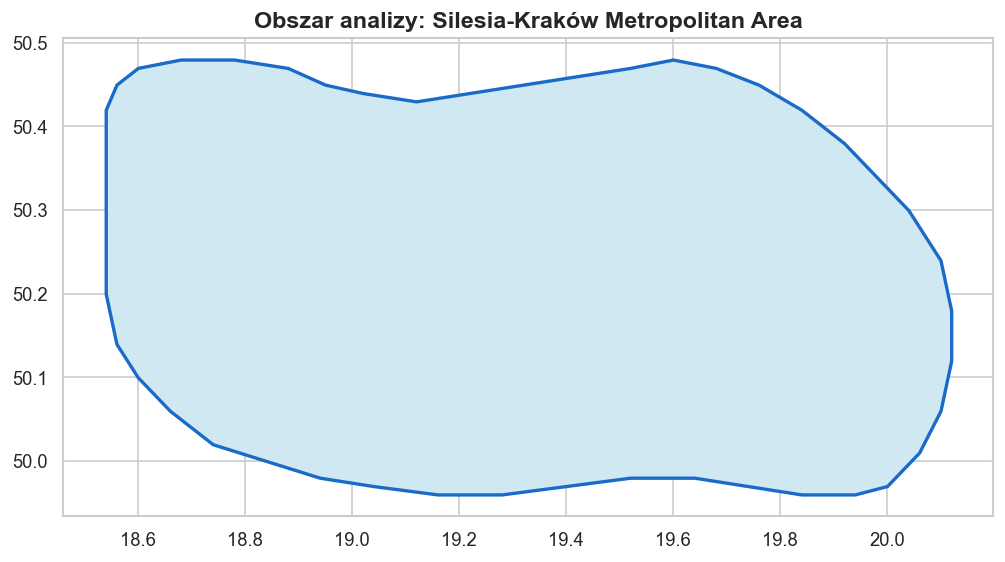

In [5]:
df_area = pd.read_csv(os.path.join(DATA_DIR, 'ds_analysis_area.csv'))

gdf_area = gpd.GeoDataFrame(
    df_area,
    geometry=df_area['geometry'].apply(wkt.loads),
    crs='EPSG:4326'
)

# Bbox wyznaczony dynamicznie z geometrii
area_geom = gdf_area.geometry.iloc[0]
minx, miny, maxx, maxy = area_geom.bounds

BBOX = {
    'lat_min': miny,
    'lat_max': maxy,
    'lng_min': minx,
    'lng_max': maxx
}

print(f"Nazwa obszaru:   {df_area['area_name'].iloc[0]}")
print(f"Typ geometrii:   {area_geom.geom_type}")
print(f"Liczba wierszy:  {len(df_area)}")
print(f"Kolumny:         {df_area.columns.tolist()}")
print()
print(f"Bbox:")
print(f"  lat: {BBOX['lat_min']:.4f} — {BBOX['lat_max']:.4f}")
print(f"  lng: {BBOX['lng_min']:.4f} — {BBOX['lng_max']:.4f}")

# Wizualizacja
fig, ax = plt.subplots(figsize=(10, 7))
gdf_area.plot(ax=ax, facecolor='#d0e8f1', edgecolor='#1a6bc9', linewidth=2)
ax.set_title(f"Obszar analizy: {df_area['area_name'].iloc[0]}",
             fontsize=14, fontweight='bold')

Teraz nakładamy dzielnice — żeby zobaczyć podział administracyjny wewnątrz obszaru.

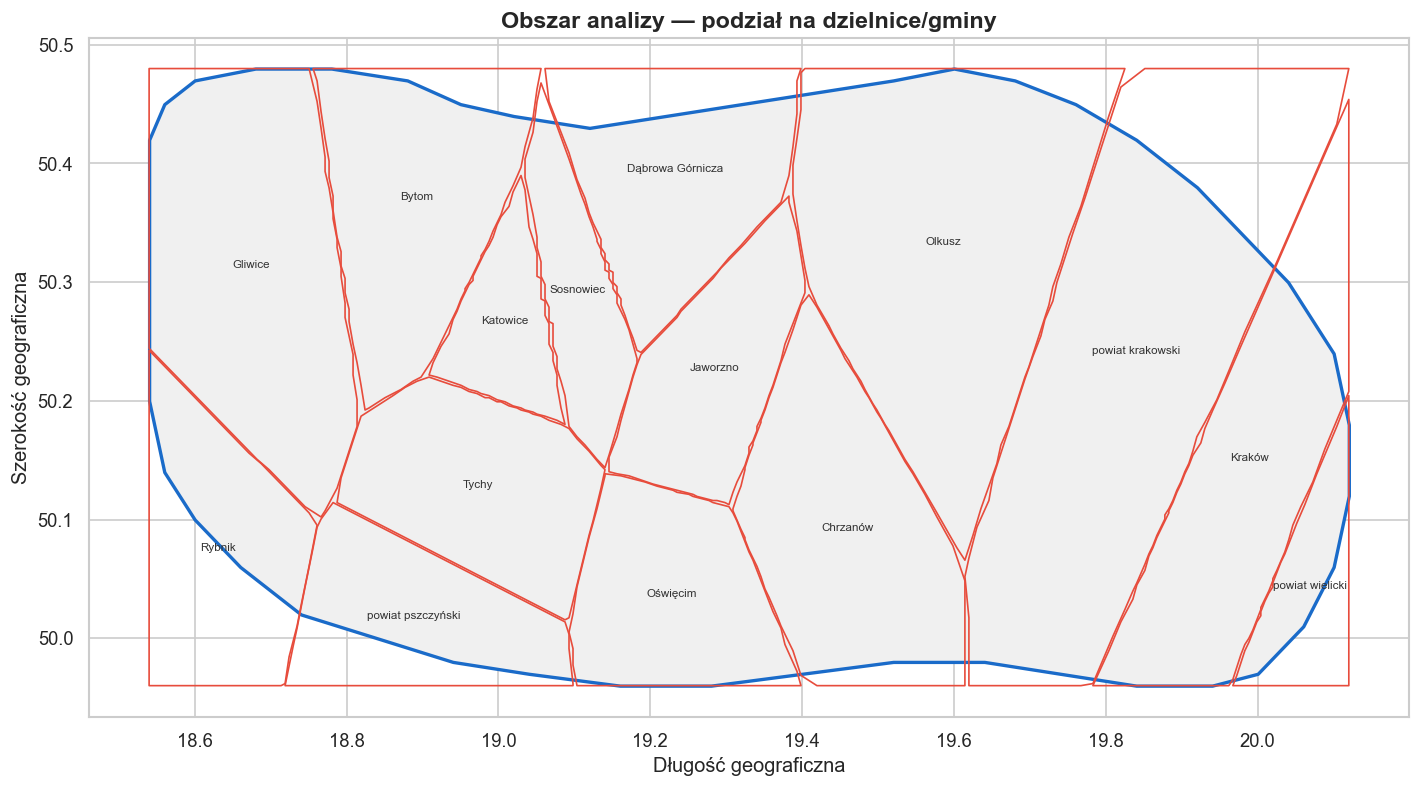

In [7]:
df_districts = pd.read_csv(os.path.join(DATA_DIR, 'ds_districts.csv'))

gdf_districts = gpd.GeoDataFrame(
    df_districts,
    geometry=df_districts['geometry'].apply(wkt.loads),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#e74c3c', linewidth=1)

for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#333333')

ax.set_title('Obszar analizy — podział na dzielnice/gminy',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
plt.tight_layout()
plt.show()

# sklepy klijenta 

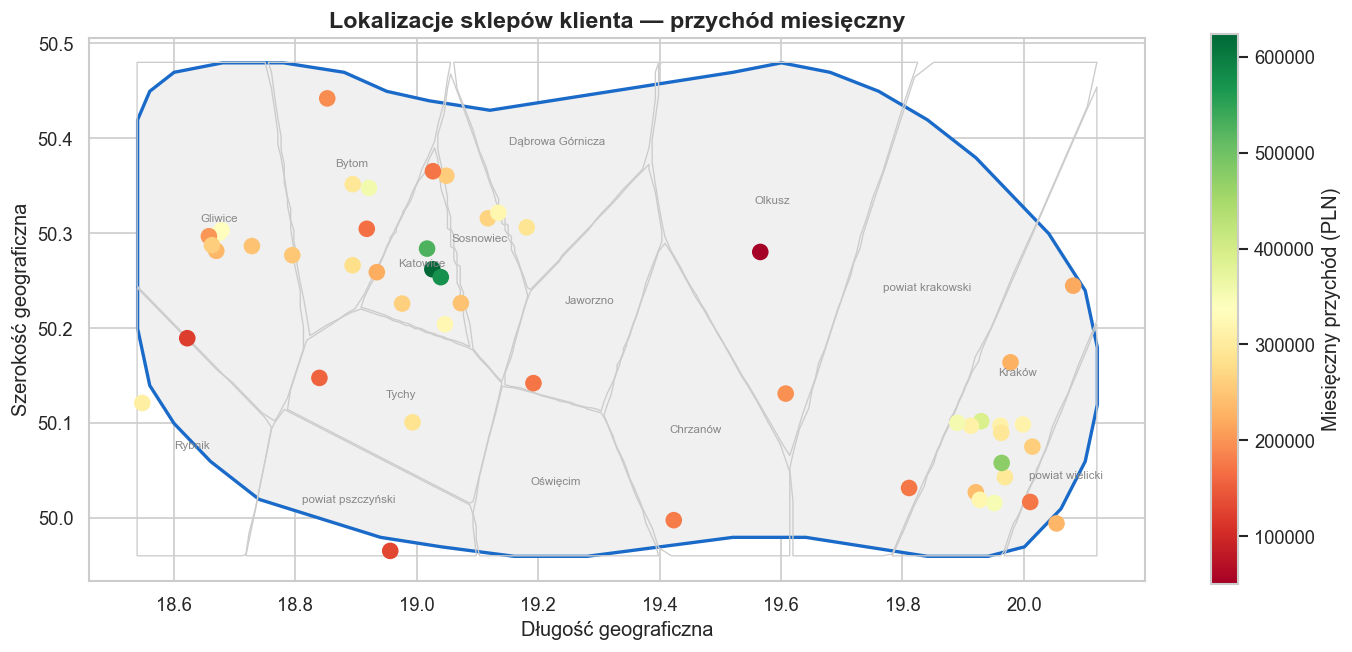

In [9]:
df_locations = pd.read_csv(os.path.join(DATA_DIR, 'ds_locations.csv'))

gdf_locations = gpd.GeoDataFrame(
    df_locations,
    geometry=gpd.points_from_xy(df_locations['lng'], df_locations['lat']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)

# Nazwy dzielnic
for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#888888')

gdf_locations.plot(ax=ax, column='monthly_revenue', cmap='RdYlGn',
                   markersize=80, legend=True,
                   legend_kwds={'label': 'Miesięczny przychód (PLN)', 'shrink': 0.6})

ax.set_title('Lokalizacje sklepów klienta — przychód miesięczny',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
plt.tight_layout()
plt.show()

# Teraz nakładamy konkurencję — żeby zobaczyć gdzie są sklepy rywali względem sklepów klienta.

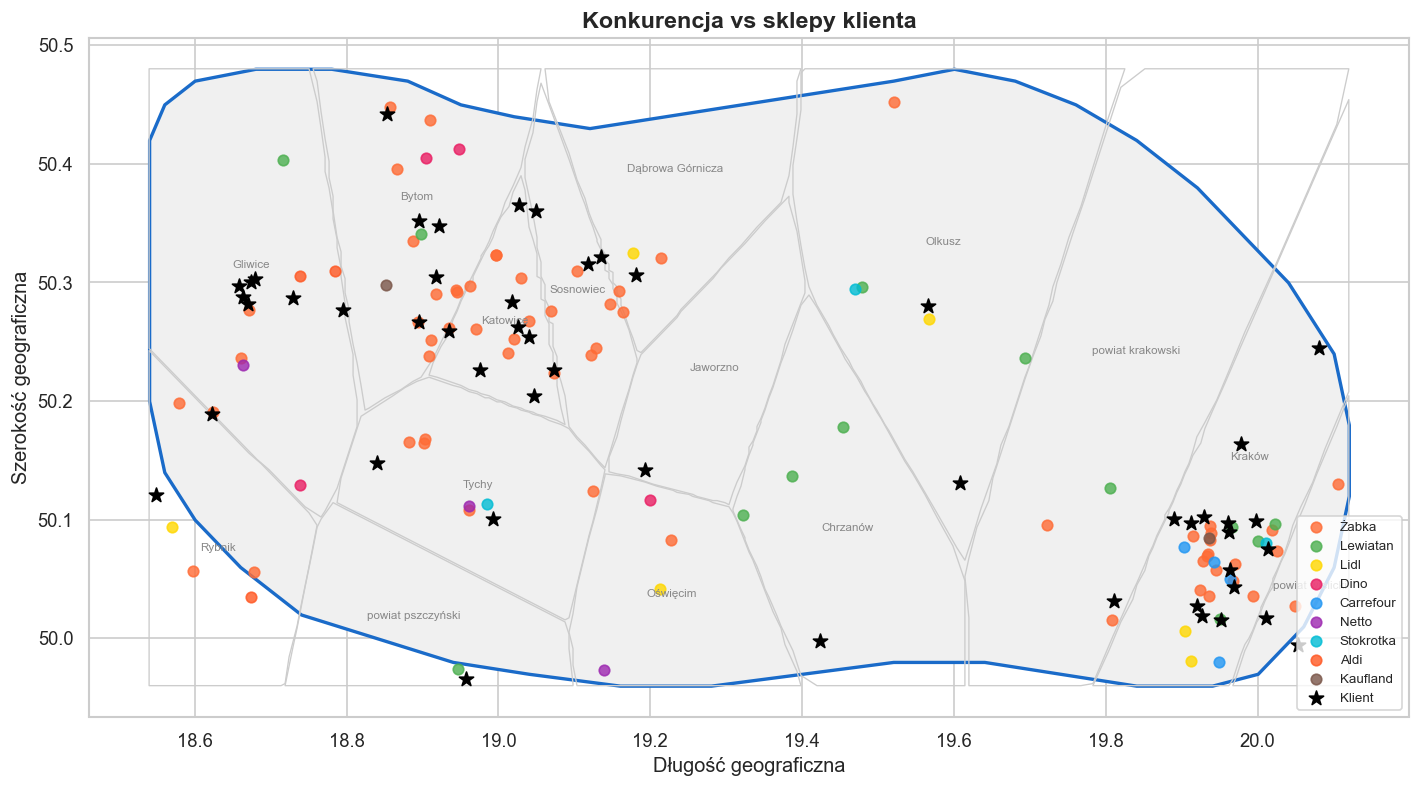

In [ ]:
df_competitors = pd.read_csv(os.path.join(DATA_DIR, 'ds_competitors.csv'))

gdf_competitors = gpd.GeoDataFrame(
    df_competitors,
    geometry=gpd.points_from_xy(df_competitors['lng'], df_competitors['lat']),
    crs='EPSG:4326'
)

brand_colors = {
    'Żabka':    '#FF6B35',
    'Lewiatan': '#4CAF50',
    'Lidl':     '#FFD700',
    'Dino':     '#E91E63',
    'Carrefour':'#2196F3',
    'Netto':    '#9C27B0',
    'Stokrotka':'#00BCD4',
    'Aldi':     '#FF5722',
    'Kaufland': '#795548'
}

fig, ax = plt.subplots(figsize=(12, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)

for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#888888')

for brand, color in brand_colors.items():
    subset = gdf_competitors[gdf_competitors['brand'] == brand]
    subset.plot(ax=ax, color=color, markersize=40, label=brand, alpha=0.8)

gdf_locations.plot(ax=ax, color='black', markersize=80,
                   marker='*', label='Klient', zorder=5)

ax.set_title('Konkurencja vs sklepy klienta', fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
df_competitors = pd.read_csv(os.path.join(DATA_DIR, 'ds_competitors.csv'))

print("=== ds_competitors.csv ===")
print(f"Shape:   {df_competitors.shape}")
print(f"Kolumny: {df_competitors.columns.tolist()}")
print()
print("Braki danych:")
display(df_competitors.isnull().sum().to_frame(name='braki'))
print()
print("Rozkład brandów:")
display(df_competitors['brand'].value_counts().to_frame())
print()
print("Statystyki współrzędnych:")
display(df_competitors[['lat', 'lng']].describe().round(4))

=== ds_competitors.csv ===
Shape:   (98, 4)
Kolumny: ['comp_id', 'brand', 'lat', 'lng']

Braki danych:


,braki
comp_id,0
brand,0
lat,0
lng,0



Rozkład brandów:


,count
brand,
Żabka,60
Lewiatan,13
Lidl,6
Dino,4
Carrefour,4
Netto,3
Stokrotka,3
Aldi,3
Kaufland,2



Statystyki współrzędnych:


,lat,lng
count,98.0000,98.0000
mean,50.1801,19.3088
std,0.1248,0.4917
min,49.9728,18.5698
25%,50.0775,18.9104
50%,50.1646,19.1339
75%,50.2877,19.9215
max,50.4518,20.1062


# Teraz POI — najpierw krótkie EDA a potem mapa.

In [13]:
df_poi = pd.read_csv(os.path.join(DATA_DIR, 'ds_poi.csv'))

print("=== ds_poi.csv ===")
print(f"Shape:   {df_poi.shape}")
print(f"Kolumny: {df_poi.columns.tolist()}")
print()
print("Braki danych:")
display(df_poi.isnull().sum().to_frame(name='braki'))
print()
print("Rozkład kategorii:")
display(df_poi['category'].value_counts().to_frame())

=== ds_poi.csv ===
Shape:   (335, 5)
Kolumny: ['poi_id', 'category', 'name', 'lat', 'lng']

Braki danych:


,braki
poi_id,0
category,0
name,0
lat,0
lng,0



Rozkład kategorii:


,count
category,
restaurant,60
school,60
bus_stop,60
park,40
pharmacy,40
bank,30
hospital,30
mall,15


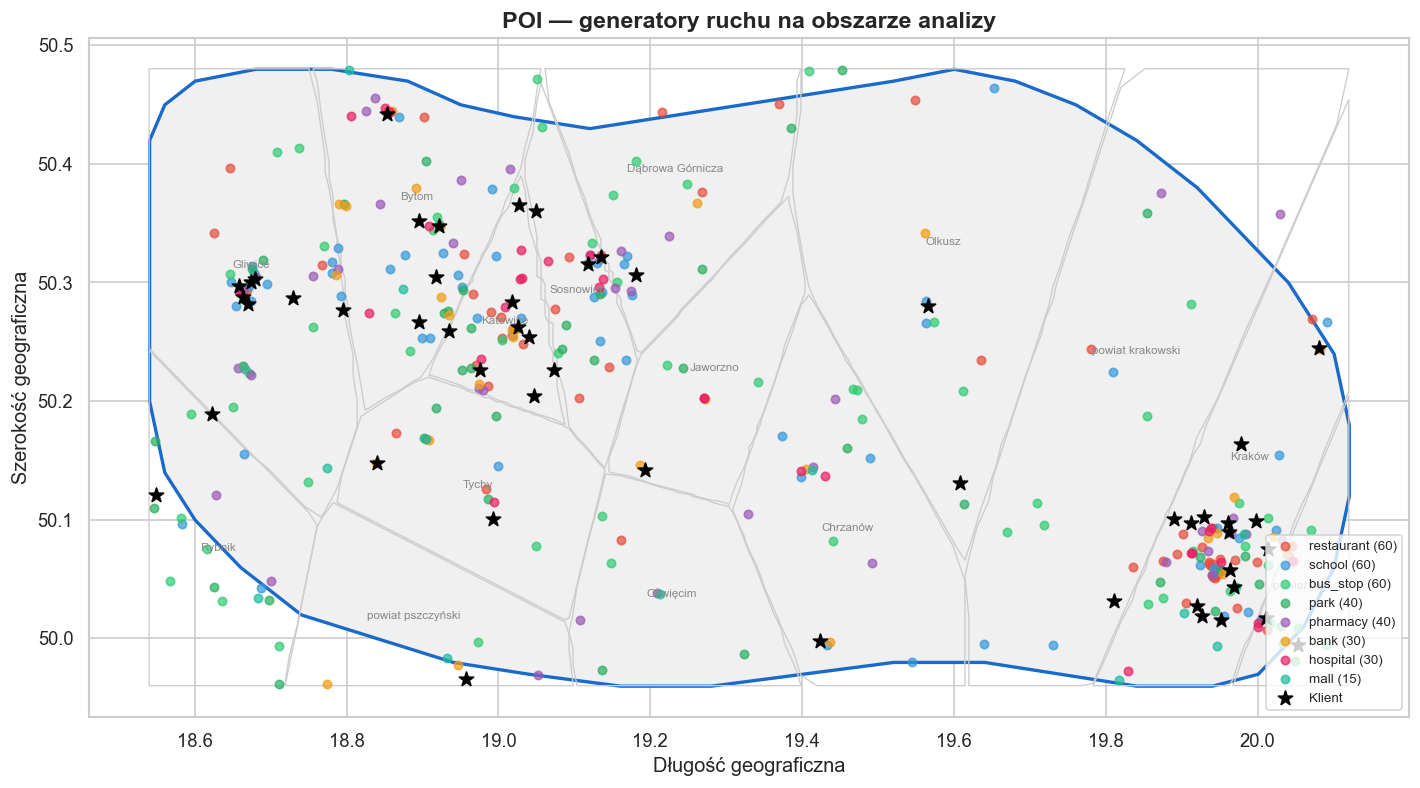

In [14]:
gdf_poi = gpd.GeoDataFrame(
    df_poi,
    geometry=gpd.points_from_xy(df_poi['lng'], df_poi['lat']),
    crs='EPSG:4326'
)

poi_colors = {
    'restaurant': '#E74C3C',
    'school':     '#3498DB',
    'bus_stop':   '#2ECC71',
    'park':       '#27AE60',
    'pharmacy':   '#9B59B6',
    'bank':       '#F39C12',
    'hospital':   '#E91E63',
    'mall':       '#1ABC9C'
}

fig, ax = plt.subplots(figsize=(12, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)

for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#888888')

for category, color in poi_colors.items():
    subset = gdf_poi[gdf_poi['category'] == category]
    subset.plot(ax=ax, color=color, markersize=25,
                label=f"{category} ({len(subset)})", alpha=0.7)

gdf_locations.plot(ax=ax, color='black', markersize=80,
                   marker='*', label='Klient', zorder=5)

ax.set_title('POI — generatory ruchu na obszarze analizy',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

# Przechodzimy do danych z AWS — populacja. Najpierw EDA:

In [15]:
df_population = pd.read_csv(
    os.path.join(DATA_DIR, 'recruitment_population.csv.gz'),
    compression='gzip'
)

print("=== recruitment_population.csv.gz ===")
print(f"Shape:   {df_population.shape}")
print(f"Kolumny: {df_population.columns.tolist()}")
print()
print("Braki danych:")
display(df_population.isnull().sum().to_frame(name='braki'))
print()
print("Statystyki:")
display(df_population[['households', 'household_size', 'total', 'male', 'female']].describe().round(2))

=== recruitment_population.csv.gz ===
Shape:   (450140, 12)
Kolumny: ['id', 'teryt', 'city', 'street', 'housenumber', 'households', 'household_size', 'total', 'male', 'female', 'lat', 'lng']

Braki danych:


,braki
id,0
teryt,0
city,0
street,33902
housenumber,0
households,0
household_size,0
total,0
male,0
female,0



Statystyki:


,households,household_size,total,male,female
count,450140.00,450140.00,450140.00,450140.00,450140.00
mean,2.91,3.57,8.08,3.83,4.25
std,7.85,3.24,18.58,8.70,10.09
min,1.00,0.00,0.00,0.00,0.00
25%,1.00,2.00,2.00,1.00,1.00
50%,1.00,3.00,4.00,2.00,2.00
75%,1.00,5.00,6.00,3.00,4.00
max,474.00,292.00,1226.00,560.00,667.00


# Teraz mapa populacji:

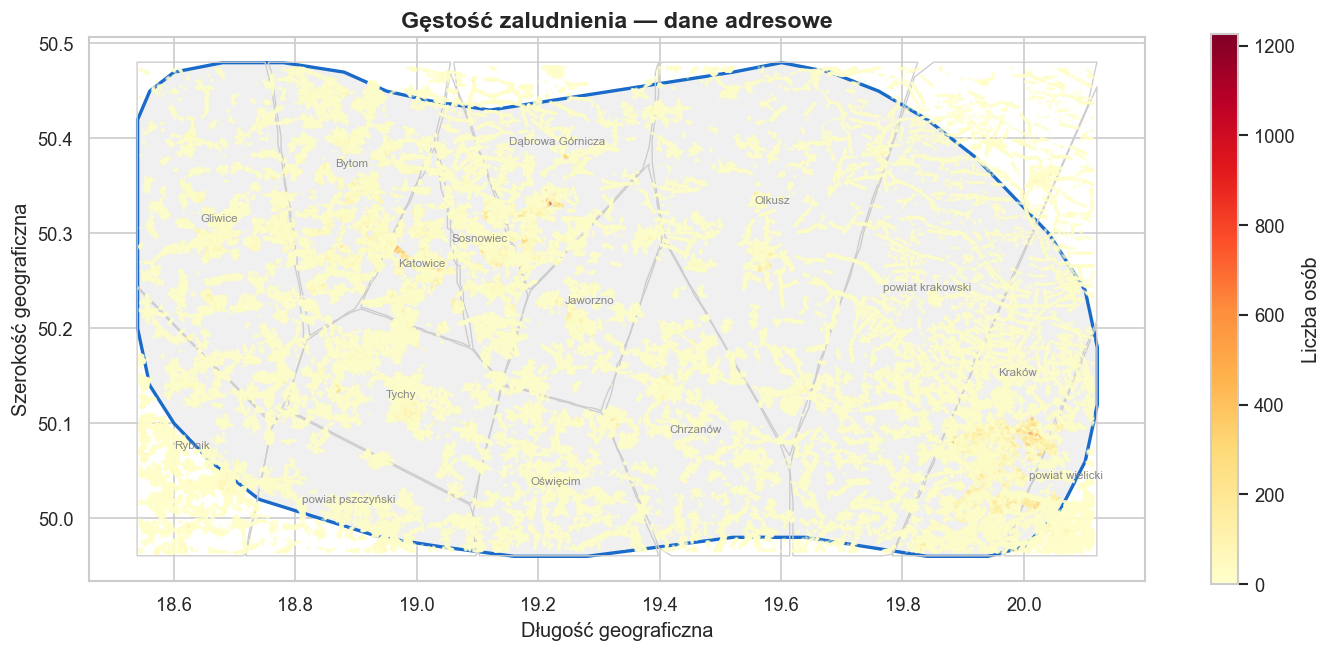

Rekordów w obszarze: 450,140 z 450,140


In [16]:
mask = (
    df_population['lat'].between(BBOX['lat_min'], BBOX['lat_max']) &
    df_population['lng'].between(BBOX['lng_min'], BBOX['lng_max'])
)
df_pop_area = df_population[mask].copy()

gdf_population = gpd.GeoDataFrame(
    df_pop_area,
    geometry=gpd.points_from_xy(df_pop_area['lng'], df_pop_area['lat']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)

for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#888888')

gdf_population.plot(ax=ax, column='total', cmap='YlOrRd',
                    markersize=1, alpha=0.3, legend=True,
                    legend_kwds={'label': 'Liczba osób', 'shrink': 0.6})

ax.set_title('Gęstość zaludnienia — dane adresowe',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
plt.tight_layout()
plt.show()

print(f"Rekordów w obszarze: {len(df_pop_area):,} z {len(df_population):,}")

# Teraz ostatni plik AWS — budynki:

In [17]:
df_buildings = pd.read_csv(
    os.path.join(DATA_DIR, 'recruitment_buildings.csv.gz'),
    compression='gzip'
)

print("=== recruitment_buildings.csv.gz ===")
print(f"Shape:   {df_buildings.shape}")
print(f"Kolumny: {df_buildings.columns.tolist()}")
print()
print("Braki danych:")
display(df_buildings.isnull().sum().to_frame(name='braki'))
print()
print("Typy budynków (top 10):")
display(df_buildings['funogolnabudynku_desc'].value_counts().head(10).to_frame())

=== recruitment_buildings.csv.gz ===
Shape:   (955612, 8)
Kolumny: ['teryt', 'lokalnyid', 'funogolnabudynku_desc', 'funszczegolowabudynku_desc', 'area', 'geometry', 'geojson', 'geohash5']

Braki danych:


,braki
teryt,0
lokalnyid,0
funogolnabudynku_desc,0
funszczegolowabudynku_desc,0
area,0
geometry,0
geojson,0
geohash5,0



Typy budynków (top 10):


,count
funogolnabudynku_desc,
budynkiMieszkalneJednorodzinne,453932
budynekGospodarstwaRolnego,289208
budynkiOTrzechIWiecejMieszkaniach,65376
budynkiODwochMieszkaniach,33738
budynkiGarazy,25812
budynkiHandlowoUslugowe,23157
budynkiPrzemyslowe,18989
zbiornikSilosIBudynkiMagazynowe,12841
budynkiBiurowe,12410


# Teraz wizualizacja budynków na mapie — parsujemy geometrie WKT i rysujemy centroidy (nie pełne polygony — za wolne przy 955k):Teraz wizualizacja budynków na mapie — parsujemy geometrie WKT i rysujemy centroidy (nie pełne polygony — za wolne przy 955k):

Budynków w obszarze: 955,612


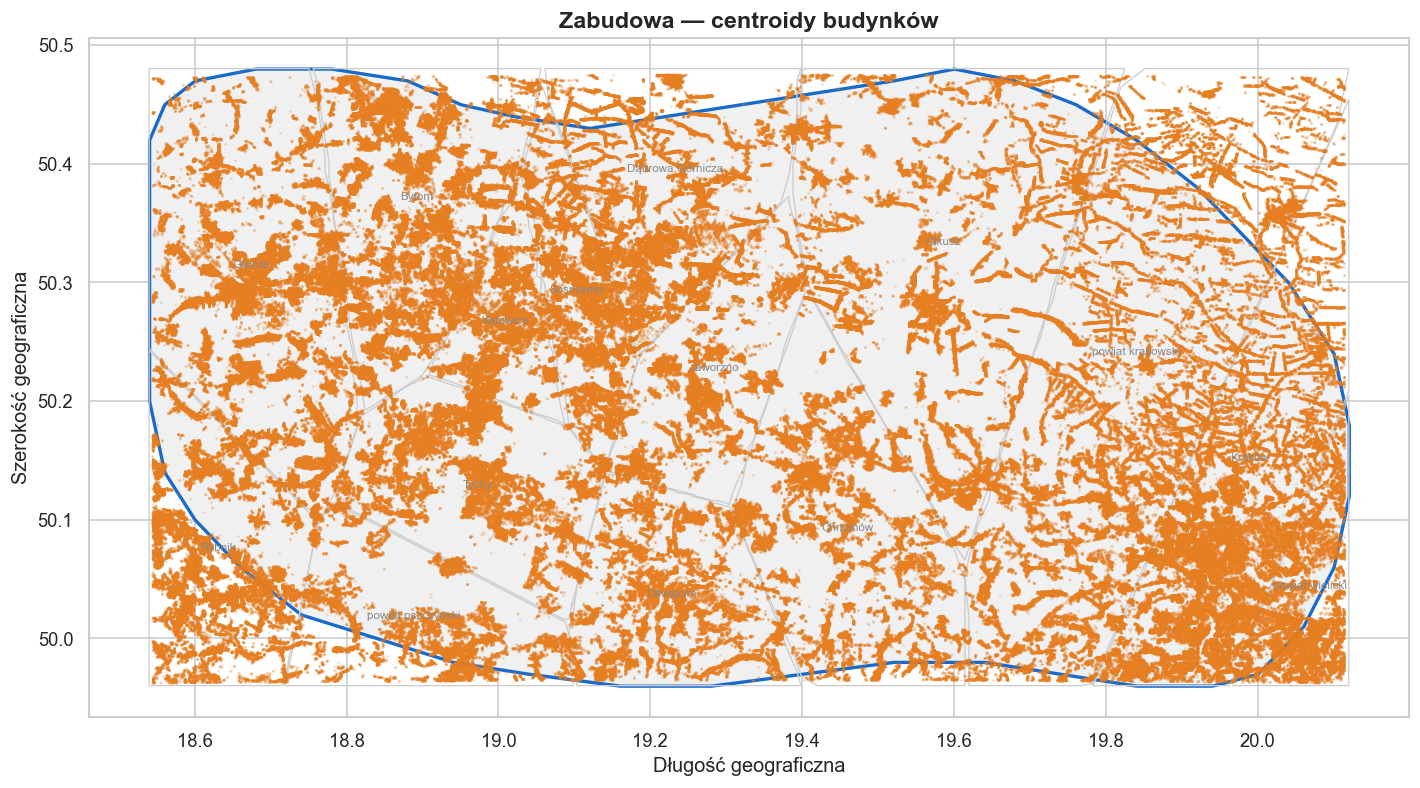

In [18]:
from shapely import wkt as swkt

def safe_centroid(geom_wkt):
    try:
        return swkt.loads(geom_wkt).centroid
    except:
        return None

df_buildings['centroid'] = df_buildings['geometry'].apply(safe_centroid)
df_buildings = df_buildings.dropna(subset=['centroid'])
df_buildings['clat'] = df_buildings['centroid'].apply(lambda g: g.y)
df_buildings['clng'] = df_buildings['centroid'].apply(lambda g: g.x)

# Filtrujemy do bbox
mask_b = (
    df_buildings['clat'].between(BBOX['lat_min'], BBOX['lat_max']) &
    df_buildings['clng'].between(BBOX['lng_min'], BBOX['lng_max'])
)
df_buildings_area = df_buildings[mask_b].copy()
print(f"Budynków w obszarze: {len(df_buildings_area):,}")

gdf_buildings = gpd.GeoDataFrame(
    df_buildings_area,
    geometry=gpd.points_from_xy(df_buildings_area['clng'], df_buildings_area['clat']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)

for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#888888')

gdf_buildings.plot(ax=ax, color='#e67e22', markersize=0.5, alpha=0.2)

ax.set_title('Zabudowa — centroidy budynków', fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
plt.tight_layout()
plt.show()

## Snowflake — RECRUITMENT_TRACES

Tabela `RECRUITMENT_TRACES` zawiera surowe sygnały lokalizacyjne z urządzeń mobilnych
zebrane w lipcu 2020 na terenie całej Polski.

| Parametr | Wartość |
|---|---|
| Liczba rekordów | ~435 mln sygnałów |
| Zakres czasowy | lipiec 2020 |
| Zasięg | cała Polska |
| Unikalni użytkownicy | ~829k |
| Aplikacje zbierające dane | 485 |

### Kluczowe kolumny
| Kolumna | Typ | Opis |
|---|---|---|
| `occured_at` | VARCHAR | Timestamp sygnału — wymaga konwersji |
| `proxi_user_id` | VARCHAR | ID anonimowego użytkownika |
| `latitude` / `longitude` | VARCHAR | Współrzędne — wymagają CAST na FLOAT |
| `geohash` | VARCHAR | Zakodowana lokalizacja |
| `app_id` | VARCHAR | ID aplikacji zbierającej sygnał |

### Strategia pracy z danymi
Tabela ma 435 mln wierszy — **nie pobieramy danych lokalnie**.
Wszystkie operacje wykonujemy jako agregacje SQL po stronie serwera Snowflake
z wykorzystaniem funkcji przestrzennych `ST_DISTANCE` i filtrowania przez bbox obszaru analizy.

In [19]:
import snowflake.connector

conn = snowflake.connector.connect(
    account=os.getenv('SF_ACCOUNT'),
    user=os.getenv('SF_USER'),
    password=os.getenv('SF_PASSWORD'),
    warehouse=os.getenv('SF_WAREHOUSE'),
    database=os.getenv('SF_DATABASE'),
    schema=os.getenv('SF_SCHEMA'),
    role=os.getenv('SF_ROLE')
)

cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM RECRUITMENT_TRACES")
total_rows = cur.fetchone()[0]

print(f"✅ Połączono ze Snowflake")
print(f"Łączna liczba sygnałów: {total_rows:,}")

✅ Połączono ze Snowflake
Łączna liczba sygnałów: 435,591,908


In [20]:
cur.execute(f"""
    SELECT COUNT(*) 
    FROM RECRUITMENT_TRACES
    WHERE TRY_TO_TIMESTAMP(occured_at) BETWEEN '2020-01-01' AND '2021-01-01'
      AND TRY_CAST(latitude  AS FLOAT) BETWEEN {BBOX['lat_min']} AND {BBOX['lat_max']}
      AND TRY_CAST(longitude AS FLOAT) BETWEEN {BBOX['lng_min']} AND {BBOX['lng_max']}
""")

area_count = cur.fetchone()[0]
print(f"Sygnałów w obszarze analizy: {area_count:,}")
print(f"Udział w całości:            {area_count/total_rows*100:.1f}%")

Sygnałów w obszarze analizy: 12,502,641
Udział w całości:            2.9%


# Teraz rozkład sygnałów wg godziny dnia:

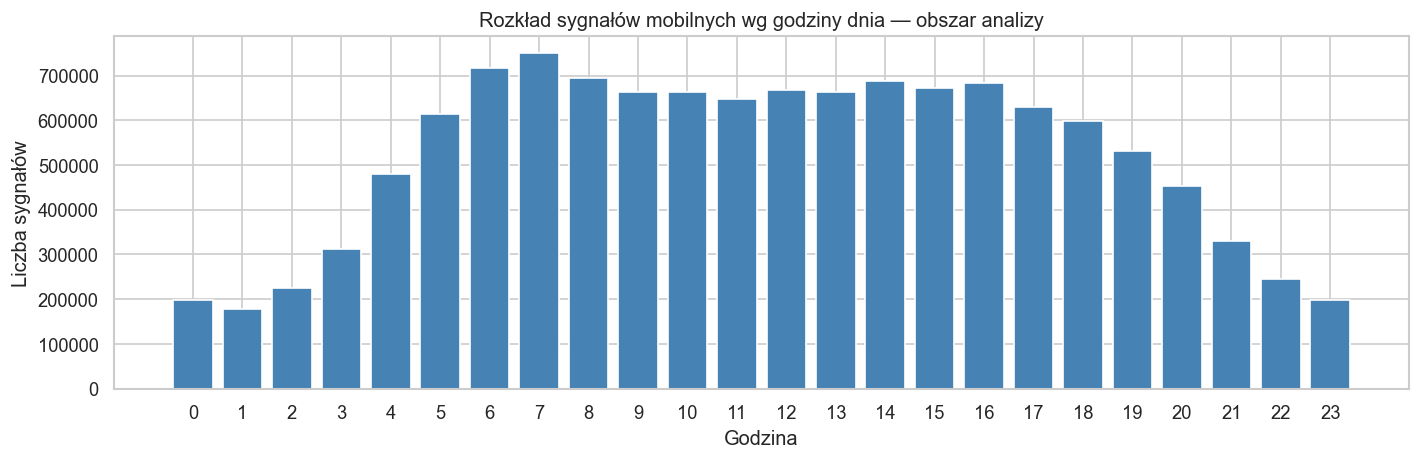

✅ Połączenie Snowflake zamknięte


In [21]:
cur.execute(f"""
    SELECT 
        HOUR(TRY_TO_TIMESTAMP(occured_at)) AS hour_of_day,
        COUNT(*)                            AS signal_count
    FROM RECRUITMENT_TRACES
    WHERE TRY_TO_TIMESTAMP(occured_at) BETWEEN '2020-01-01' AND '2021-01-01'
      AND TRY_CAST(latitude  AS FLOAT) BETWEEN {BBOX['lat_min']} AND {BBOX['lat_max']}
      AND TRY_CAST(longitude AS FLOAT) BETWEEN {BBOX['lng_min']} AND {BBOX['lng_max']}
    GROUP BY 1
    ORDER BY 1
""")

df_hourly = pd.DataFrame(cur.fetchall(), columns=['hour', 'signal_count'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_hourly['hour'], df_hourly['signal_count'], color='steelblue', edgecolor='white')
ax.set_title('Rozkład sygnałów mobilnych wg godziny dnia — obszar analizy')
ax.set_xlabel('Godzina')
ax.set_ylabel('Liczba sygnałów')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

conn.close()
print("✅ Połączenie Snowflake zamknięte")

# rozkład wg dnia tygodnia:

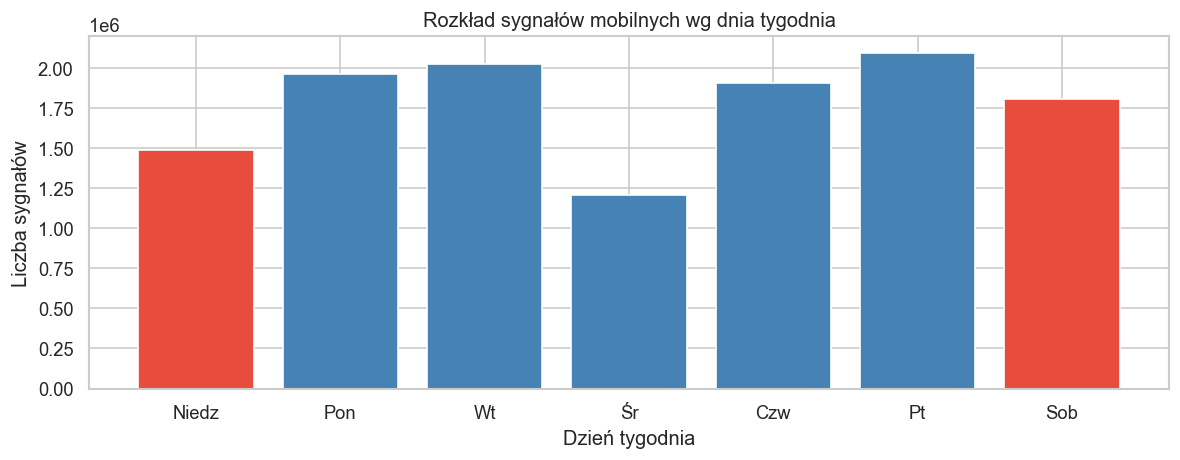

In [22]:
conn = snowflake.connector.connect(
    account=os.getenv('SF_ACCOUNT'),
    user=os.getenv('SF_USER'),
    password=os.getenv('SF_PASSWORD'),
    warehouse=os.getenv('SF_WAREHOUSE'),
    database=os.getenv('SF_DATABASE'),
    schema=os.getenv('SF_SCHEMA'),
    role=os.getenv('SF_ROLE')
)
cur = conn.cursor()

cur.execute(f"""
    SELECT 
        DAYOFWEEK(TRY_TO_TIMESTAMP(occured_at)) AS day_of_week,
        COUNT(*)                                 AS signal_count
    FROM RECRUITMENT_TRACES
    WHERE TRY_TO_TIMESTAMP(occured_at) BETWEEN '2020-01-01' AND '2021-01-01'
      AND TRY_CAST(latitude  AS FLOAT) BETWEEN {BBOX['lat_min']} AND {BBOX['lat_max']}
      AND TRY_CAST(longitude AS FLOAT) BETWEEN {BBOX['lng_min']} AND {BBOX['lng_max']}
    GROUP BY 1
    ORDER BY 1
""")

df_daily = pd.DataFrame(cur.fetchall(), columns=['day_of_week', 'signal_count'])
df_daily['day_name'] = ['Niedz', 'Pon', 'Wt', 'Śr', 'Czw', 'Pt', 'Sob']

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if d in [0, 6] else 'steelblue' for d in df_daily['day_of_week']]
ax.bar(df_daily['day_name'], df_daily['signal_count'], color=colors, edgecolor='white')
ax.set_title('Rozkład sygnałów mobilnych wg dnia tygodnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Liczba sygnałów')
plt.tight_layout()
plt.show()

# rozkład wg tygodnia miesiąca:

In [25]:
cur.execute(f"""
    SELECT 
        DATE(TRY_TO_TIMESTAMP(occured_at)) AS day,
        COUNT(*) AS signal_count
    FROM RECRUITMENT_TRACES
    WHERE TRY_TO_TIMESTAMP(occured_at) BETWEEN '2020-07-01' AND '2020-07-31'
      AND TRY_CAST(latitude  AS FLOAT) BETWEEN {BBOX['lat_min']} AND {BBOX['lat_max']}
      AND TRY_CAST(longitude AS FLOAT) BETWEEN {BBOX['lng_min']} AND {BBOX['lng_max']}
    GROUP BY 1
    ORDER BY 1
""")

df_daily_july = pd.DataFrame(cur.fetchall(), columns=['day', 'signal_count'])
print(f"Liczba dni z danymi w lipcu: {len(df_daily_july)}")
display(df_daily_july)

Liczba dni z danymi w lipcu: 9


,day,signal_count
0,2020-07-01,1155582
1,2020-07-02,1854429
2,2020-07-03,2016536
3,2020-07-04,1730362
4,2020-07-05,1415341
5,2020-07-06,1834858
6,2020-07-07,1627908
7,2020-07-08,473
8,2020-07-09,10


In [26]:
cur.execute(f"""
    SELECT 
        geohash,
        COUNT(*) AS signal_count
    FROM RECRUITMENT_TRACES
    WHERE TRY_CAST(latitude  AS FLOAT) BETWEEN {BBOX['lat_min']} AND {BBOX['lat_max']}
      AND TRY_CAST(longitude AS FLOAT) BETWEEN {BBOX['lng_min']} AND {BBOX['lng_max']}
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 500
""")

df_geohash = pd.DataFrame(cur.fetchall(), columns=['geohash', 'signal_count'])
print(f"Top geohash: {len(df_geohash)} rekordów")
display(df_geohash.head(10))

Top geohash: 500 rekordów


,geohash,signal_count
0,u2vmpc0x,16833
1,u2yhqpx,15351
2,u2yhqpw,15136
3,u2yjj7d,14641
4,u2yhzp1r,12518
5,u2vmxke2,10262
6,u2vq5ts,10186
7,u2vq5td7,7529
8,u2vtf6r3,7414
9,u2vq0g2m,7156


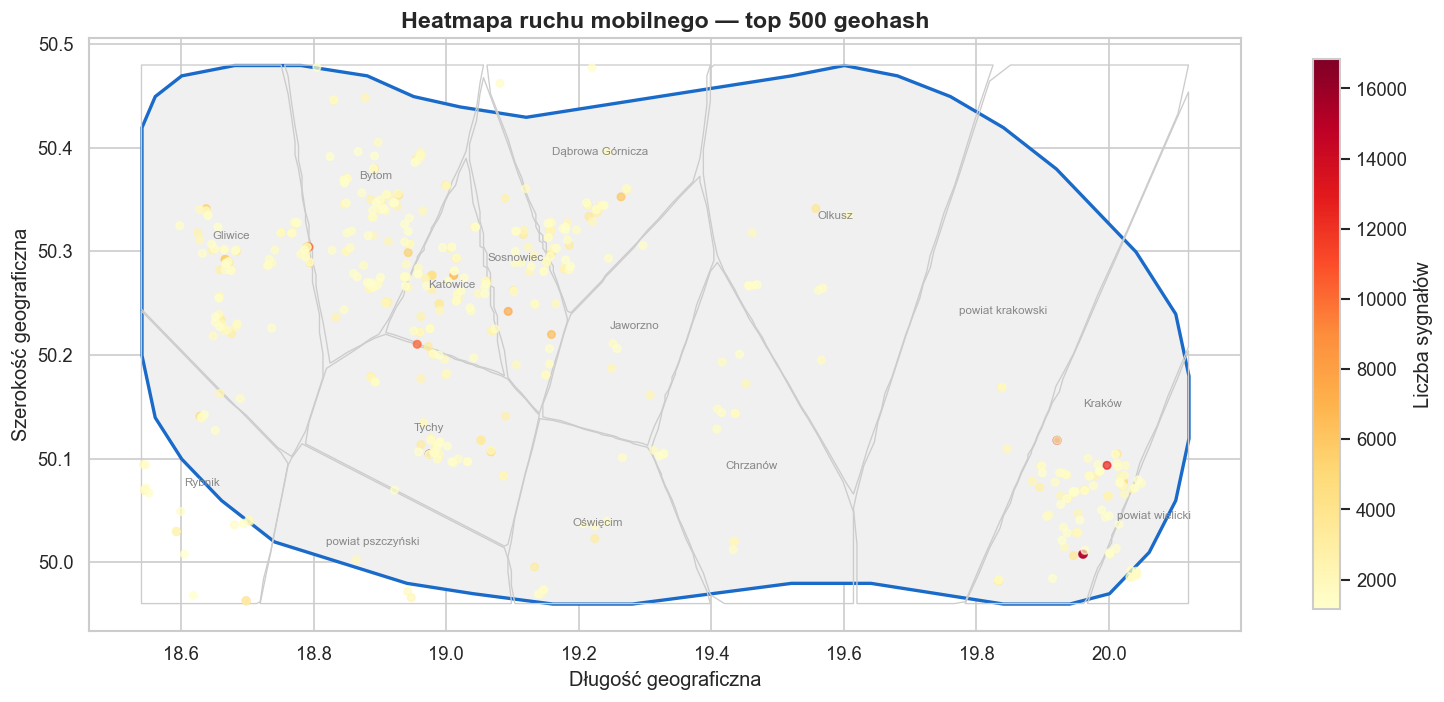

In [27]:
import math

def geohash_decode(geohash):
    base32 = '0123456789bcdefghjkmnpqrstuvwxyz'
    is_lon = True
    lat_min, lat_max = -90.0, 90.0
    lon_min, lon_max = -180.0, 180.0
    
    for char in geohash:
        cd = base32.index(char)
        for mask in [16, 8, 4, 2, 1]:
            if is_lon:
                mid = (lon_min + lon_max) / 2
                if cd & mask:
                    lon_min = mid
                else:
                    lon_max = mid
            else:
                mid = (lat_min + lat_max) / 2
                if cd & mask:
                    lat_min = mid
                else:
                    lat_max = mid
            is_lon = not is_lon
    
    return (lat_min + lat_max) / 2, (lon_min + lon_max) / 2

df_geohash['lat'] = df_geohash['geohash'].apply(lambda x: geohash_decode(x)[0])
df_geohash['lng'] = df_geohash['geohash'].apply(lambda x: geohash_decode(x)[1])

# Filtrujemy do bbox
mask_g = (
    df_geohash['lat'].between(BBOX['lat_min'], BBOX['lat_max']) &
    df_geohash['lng'].between(BBOX['lng_min'], BBOX['lng_max'])
)
df_geohash_area = df_geohash[mask_g].copy()

gdf_geohash = gpd.GeoDataFrame(
    df_geohash_area,
    geometry=gpd.points_from_xy(df_geohash_area['lng'], df_geohash_area['lat']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(13, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)

for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#888888')

gdf_geohash.plot(ax=ax, column='signal_count', cmap='YlOrRd',
                 markersize=20, alpha=0.7, legend=True,
                 legend_kwds={'label': 'Liczba sygnałów', 'shrink': 0.6})

ax.set_title('Heatmapa ruchu mobilnego — top 500 geohash',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
plt.tight_layout()
plt.show()

# unikalni użytkownicy per dzień:
python

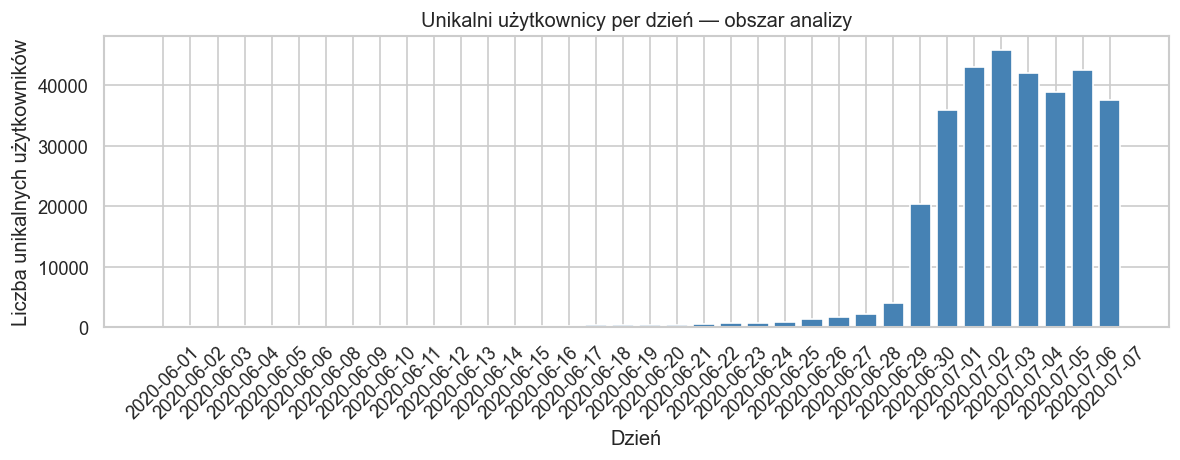

✅ Połączenie Snowflake zamknięte


In [28]:
cur.execute(f"""
    SELECT 
        DATE(TRY_TO_TIMESTAMP(occured_at))  AS day,
        COUNT(DISTINCT proxi_user_id)        AS unique_users
    FROM RECRUITMENT_TRACES
    WHERE TRY_CAST(latitude  AS FLOAT) BETWEEN {BBOX['lat_min']} AND {BBOX['lat_max']}
      AND TRY_CAST(longitude AS FLOAT) BETWEEN {BBOX['lng_min']} AND {BBOX['lng_max']}
    GROUP BY 1
    ORDER BY 1
""")

df_users = pd.DataFrame(cur.fetchall(), columns=['day', 'unique_users'])
df_users = df_users[df_users['unique_users'] > 100]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_users['day'].astype(str), df_users['unique_users'], 
       color='steelblue', edgecolor='white')
ax.set_title('Unikalni użytkownicy per dzień — obszar analizy')
ax.set_xlabel('Dzień')
ax.set_ylabel('Liczba unikalnych użytkowników')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

conn.close()
print("✅ Połączenie Snowflake zamknięte")

In [29]:
conn = snowflake.connector.connect(
    account=os.getenv('SF_ACCOUNT'),
    user=os.getenv('SF_USER'),
    password=os.getenv('SF_PASSWORD'),
    warehouse=os.getenv('SF_WAREHOUSE'),
    database=os.getenv('SF_DATABASE'),
    schema=os.getenv('SF_SCHEMA'),
    role=os.getenv('SF_ROLE')
)
cur = conn.cursor()

cur.execute("SHOW COLUMNS IN TABLE RECRUITMENT_TRACES")
columns = cur.fetchall()

for col in columns:
    print(f"{col[2]:<25} {col[3]}")

OCCURED_AT                {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
APP_ID                    {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
PROXI_USER_ID             {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
LATITUDE                  {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
LONGITUDE                 {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
GEOHASH                   {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
PAIRING_ID                {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
MAC_ADDRESS               {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed":false}
RSSI                      {"type":"TEXT","length":16777216,"byteLength":16777216,"nullable":true,"fixed"

In [30]:
cur.execute(f"""
    SELECT 
        OCCURED_AT,
        PROXI_USER_ID,
        TRY_CAST(LATITUDE  AS FLOAT) AS LATITUDE,
        TRY_CAST(LONGITUDE AS FLOAT) AS LONGITUDE
    FROM RECRUITMENT_TRACES
    WHERE TRY_TO_TIMESTAMP(OCCURED_AT) BETWEEN '2020-07-01' AND '2020-07-08'
      AND TRY_CAST(LATITUDE  AS FLOAT) BETWEEN {BBOX['lat_min']} AND {BBOX['lat_max']}
      AND TRY_CAST(LONGITUDE AS FLOAT) BETWEEN {BBOX['lng_min']} AND {BBOX['lng_max']}
""")

df_traces = pd.DataFrame(cur.fetchall(), 
                          columns=['occured_at', 'proxi_user_id', 'latitude', 'longitude'])

print(f"✅ Pobrano: {len(df_traces):,} rekordów")
print(f"Rozmiar w pamięci: {df_traces.memory_usage(deep=True).sum()/1024/1024:.1f} MB")

✅ Pobrano: 11,635,016 rekordów
Rozmiar w pamięci: 2113.0 MB


In [31]:
TRACES_PATH = r"C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\raw\traces_area.csv.gz"

df_traces.to_csv(TRACES_PATH, index=False, compression='gzip')
print(f"✅ Zapisano do {TRACES_PATH}")

# Zwolnienie pamięci
del df_traces
import gc
gc.collect()
print("✅ Pamięć zwolniona")

conn.close()
print("✅ Połączenie Snowflake zamknięte")

✅ Zapisano do C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\raw\traces_area.csv.gz
✅ Pamięć zwolniona
✅ Połączenie Snowflake zamknięte
